In [6]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [7]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [8]:
arxiv.invoke("what is attention mechanisim")

'Published: 2025-02-22\nTitle: Pay Attention to What You Need\nAuthors: Yifei Gao, Shaohong Chen, Lei Wang, Ruiting Dai, Ziyun Zhang, Kerui Ren, Jiaji Wu, Jun Cheng\nSummary: Although large language models (LLMs) have achieved significant success in natural language processing, they still struggle with long-context comprehension. Traditional approaches to mitigating this issue typically rely on fine-tuning or retraining, which is both resource-intensive and challenging to deploy in lightweight indus'

In [9]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [10]:
wiki.invoke("what is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [11]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['TAVILY_API_KEY']=os.getenv('TAVILY_API_KEY')
os.environ['GRPQ_API_KEY']=os.getenv('GROQ_API_KEY')

In [12]:
### Tavily search tools
from langchain_community.tools.tavily_search import TavilySearchResults
tavily=TavilySearchResults()

C:\Users\anves\AppData\Local\Temp\ipykernel_696\3173510067.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [13]:
tavily.invoke('what is current news in khammam')

[{'title': 'Latest Khammam News, Photos, Latest News Headlines about ...',
  'url': 'https://www.thehindu.com/tag/88-86-81/',
  'content': '### With Dalit Bandhu, drone sprayer operators soar to dizzying heights\n\n### Three feared drowned in NSP irrigation canal, near Khammam\n\nVehicles stopped during the Sadak Bandh at Konjerla of Khammam District on Tuesday.\n\n### 5-hour Sadak Bandh disrupts highway traffic\n\nCPI candidates who won their respective wards showing the victory symbol at KMC elections counting center in Khammam on Monday. \n\n### TRS registers an emphatic victory in Khammam civic polls\n\nBJP candidate Premendar Reddy at a hospital in  Khammam . G N RAO\n\n### BJP candidate alleges attack by TRS cadre\n\nOver 1.29 lakh voters are expected to exercise their right to vote in today’s election in the erstwhile composite Khammam district. [...] ### Sub-Registrar, document writer caught accepting bribe in Khammam\n\n### Three-day SFI State conference to be held in Khammam 

In [14]:
## combine all tools
tools=[arxiv,wiki,tavily]

In [15]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")
llm_with_tools=llm.bind_tools(tools)

In [16]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage
llm_with_tools.invoke([HumanMessage(content=f'what is recent news about AI')])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news about AI. Let me think about which tool to use here. The available tools are arxiv, wikipedia, and tavily_search_results_json.\n\nArxiv is for scientific papers, so maybe not the best choice for recent news. Wikipedia is good for general information but might not have the latest updates. The tavily_search_results_json is described as a search engine optimized for current events. That sounds like the right tool here since the user wants recent news. \n\nI should call tavily_search_results_json with a query for "recent AI news" or "latest AI developments". Let me make sure the parameters are correct. The function requires a "query" parameter, which I\'ll set to "recent AI news". \n\nI need to structure the tool call properly. The name of the function is tavily_search_results_json, and the arguments are a JSON object with the query. Let me double-check the syntax. Yes, the required form

In [21]:
### Entire ChatBot with LangGraph

In [22]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [25]:
from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node Definition
def tool_calling_llm(state:State):
   return{"messages":[llm_with_tools.invoke(state['messages'])]}
    

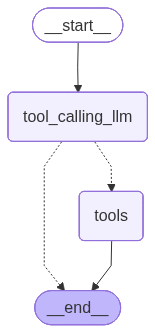

In [32]:
builder=StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # if the latest message (result) from assistant is a tool call->tools condition route to tools
    # if the latest message(result) from assistant is not a tool call -> tool condition routes to end
    tools_condition,
)
builder.add_edge('tools',END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage
messages=graph.invoke({"messages":HumanMessage(content=f'1706.03762')})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (0nar6fccw)
 Call ID: 0nar6fccw
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [2]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['TAVILY_API_KEY']=os.getenv('TAVILY_API_KEY')
os.environ['GRPQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['LANGCHAIN_API_KEY']=os.getenv('LANGCHAIN_API_KEY')
os.environ['LANGCHAIN_TRACING_V2']='true'
os.environ['LANGCHAIN_PROJECT']='ReAct-agent'

In [17]:
##custom functions
def multiply(a:int,b:int):
    """""multiply a and b
    Args:
        a:first int
        b:second int
    """
    return a*b

def add(a:int,b:int):
    """add a and b
    
    Args:
        a: first int
        b: second int"""
    return a+b

def division(a:int,b:int):
    """divide a and b
    
    Args:
        a:first int
        b:second int"""
    return a/b
tools=[arxiv,wiki,add,multiply,division]

In [19]:
from langchain_community.tools .tavily_search import TavilySearchResults
tavily=TavilySearchResults()
tavily.invoke("what is recent news on AI")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com/',
  'content': 'Artificial Intelligence\n\nOctober 7, 2025\n\n### Spot AI introduces the world’s first universal AI agent builder for security cameras\n\nArtificial Intelligence\n\nApril 10, 2025\n\n### Tony Blair Institute AI copyright report sparks backlash\n\nArtificial Intelligence\n\nApril 2, 2025\n\n#### Enterprise\n\n### Scaling AI value beyond pilot phase purgatory\n\nAI Business Strategy\n\nJanuary 19, 2026\n\n### Meeting the new ETSI standard for AI security\n\nGovernance, Regulation & Policy\n\nJanuary 15, 2026\n\n### Allister Frost: Tackling workforce anxiety for AI integration success\n\nAI and Us\n\nJanuary 13, 2026\n\n#### Industries\n\n### Grab brings robotics in-house to manage delivery costs\n\nAI Mergers & Acquisitions\n\nJanuary 7, 2026\n\n### The Law Society: Current laws are fit for the AI era\n\nLegal Industry AI [...] Retail & 

In [23]:
tools=[arxiv,wiki,tavily,add,multiply,division]

In [24]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")
llm_with_tools=llm.bind_tools(tools)

In [25]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage
llm_with_tools.invoke("what is recent news in AI")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news in AI. I need to figure out which tool to use here. Let me check the available functions.\n\nThere\'s the arxiv function for academic papers, wikipedia for general info, tavily_search for current events, and then add, multiply, divide for math. \n\nSince the user wants recent news, which is current events, the tavily_search_results_json function seems appropriate. It\'s optimized for accurate and up-to-date results. \n\nI should structure the query to get the latest AI news. Maybe use keywords like "recent advancements in AI 2024" or "latest AI developments". Let me make sure the function is called correctly with the right parameters. \n\nThe parameters require a query string. Let\'s go with "recent advancements in AI" as the search term. That should fetch the latest news articles. Alright, I\'ll generate the tool call with that query.\n', 'tool_calls': [{'id': 'aknbxxqmk', 'function

In [26]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [27]:
from IPython.display import display,Image
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node Definition
def tool_calling_llm(state:State):
   return{"messages":[llm_with_tools.invoke(state['messages'])]}
    

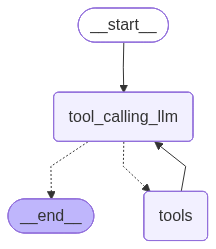

In [ ]:
builder=StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # if the latest message (result) from assistant is a tool call->tools condition route to tools
    # if the latest message(result) from assistant is not a tool call -> tool condition routes to end
    tools_condition,
)
builder.add_edge('tools','tool_calling_llm')
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
messages=graph.invoke({"messages":HumanMessage(content=f'provide me recent AI news on 1/20/2026')})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

provide me recent AI news on 1/20/2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (edb36b4v6)
 Call ID: edb36b4v6
  Args:
    query: recent AI news on 1/20/2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "Date: January 5, 2026\n\nSummary: Arkansas state officials have announced the upcoming installation of new AI-powered camera technology designed to detect drivers using handheld cell phones in highway work zones. Building on existing speed enforcement systems permitted under Act 707, these updated cameras use artificial intelligence to identify specific visual indicators, such as a phone in a driver's

In [34]:
messages=graph.invoke({"messages":HumanMessage(content=f'add 5 plus 5 and divide by 2')})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 5 plus 5 and divide by 2
================================== Ai Message ==================================
Tool Calls:
  add (bynbesqsy)
 Call ID: bynbesqsy
  Args:
    a: 5
    b: 5
  division (jtrb075pq)
 Call ID: jtrb075pq
  Args:
    a: 10
    b: 2
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: division

5.0


In [35]:
messages=graph.invoke({'messages':HumanMessage(content=f'divide that by 5')})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

divide that by 5
================================== Ai Message ==================================

I need to know the value of "that" to divide it by 5. Could you please provide the number you'd like divided by 5?


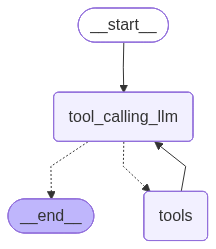

In [38]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver
graph_memory=builder.compile(checkpointer=memory)

builder=StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # if the latest message (result) from assistant is a tool call->tools condition route to tools
    # if the latest message(result) from assistant is not a tool call -> tool condition routes to end
    tools_condition,
)
builder.add_edge('tools','tool_calling_llm')
display(Image(graph_memory.get_graph().draw_mermaid_png()))


In [45]:
## specify the treads
config={'configurable':{'thread_id':'1'}}

messages=[HumanMessage(content=f'divide that by 5')]
messages=graph_memory.invoke({'messages':messages},config)
for m in messages['messages']:
    m.pretty_print()


TypeError: InMemorySaver.get_tuple() missing 1 required positional argument: 'config'